# 面向对象编程

陆老师给的建议：作为一个程序，至少要有main函数。有的功能要封装成函数，有的要封装成类。

### 你是上帝

class 类 (人) instance 实例 (你,我,他) 你会有些属性(身高,年龄,体重) 你会有些技能(吃饭,泡妞)

__init__ 方法的主要作用,就是初始化你的属性,这些属性,在上帝初始化你的时候就要赋予给你,比如zhangsan = Person(170,29,50)这时上帝就把你创造出来了，也就是实例化了你，然后，你到底有哪些技能呢，这就看有没有在类里面定义了，如果有定义泡妞的技能，那么你就可以调用泡妞的技能来泡妞，大致就是这样吧，看看下面的例子就更清楚了

In [1]:
class Person(object):
# 这里就是初始化你将要创建的实例的属性
    def __init__(self,hight,weight,age):
        self.hight = hight
        self.weight = weight
        self.age = age

# 定义你将要创建的实例所有用的技能
    def paoniu(self):
        print('你拥有泡妞的技能')

    def eat(self):
        print('you can eat')

# 开始创建实例
zhangsan=Person(170,50,29)
lisi = Person(175,100,30)

# 你的实例开始使用它的技能
zhangsan.paoniu()

你拥有泡妞的技能


通过定义一个特殊的__init__方法，在创建实例的时候，就把name，score等属性绑上去：

In [2]:
class Student(object):
    def __init__(self, name, score):
        self.name = name
        self.score = score


注意到__init__方法的第一个参数永远是self，表示创建的实例本身，因此，在__init__方法内部，就可以把各种属性绑定到self，因为self就指向创建的实例本身。

有了__init__方法，在创建实例的时候，就不能传入空的参数了，必须传入与__init__方法匹配的参数，但self不需要传，Python解释器自己会把实例变量传进去：

In [ ]:
>>> bart = Student('Bart Simpson', 59)
>>> bart.name
'Bart Simpson'
>>> bart.score
59

# 数据封装

面向对象编程的一个重要特点就是数据封装。在上面的Student类中，每个实例就拥有各自的name和score这些数据。我们可以通过函数来访问这些数据，比如打印一个学生的成绩：

In [ ]:
>>> def print_score(std):
...     print('%s: %s' % (std.name, std.score))
...
>>> print_score(bart)
Bart Simpson: 59


但是，既然Student实例本身就拥有这些数据，要访问这些数据，就没有必要从外面的函数去访问，可以直接在Student类的内部定义访问数据的函数，这样，就把“数据”给封装起来了。这些封装数据的函数是和Student类本身是关联起来的，我们称之为类的方法：

In [ ]:
class Student(object):
    def __init__(self, name, score):
        self.name = name
        self.score = score

    def print_score(self):
        print('%s: %s' % (self.name, self.score))

封装的另一个好处是可以给Student类增加新的方法，比如get_grade：

In [ ]:
class Student(object):
    ...

    def get_grade(self):
        if self.score >= 90:
            return 'A'
        elif self.score >= 60:
            return 'B'
        else:
            return 'C'


同样的，get_grade方法可以直接在实例变量上调用，不需要知道内部实现细节：

In [5]:
class Student(object):
    def __init__(self, name, score):
        self.name = name
        self.score = score

    def get_grade(self):
        if self.score >= 90:
            return 'A'
        elif self.score >= 60:
            return 'B'
        else:
            return 'C'

lisa = Student('Lisa', 99)
bart = Student('Bart', 59)
print(lisa.name, lisa.get_grade())
print(bart.name, bart.get_grade())

Lisa A
Bart C


源码

In [ ]:
class Student(object):

    def __init__(self, name, score):
        self.name = name
        self.score = score

    def print_score(self):
        print("%s: %s" % (self.name, self.score))

    def get_grade(self):
        if self.score >= 90:
            return "A"
        elif self.score >= 60:
            return "B"
        else:
            return "C"


bart = Student("Bart Simpson", 59)
lisa = Student("Lisa Simpson", 87)

print("bart.name =", bart.name)
print("bart.score =", bart.score)
bart.print_score()

print("grade of Bart:", bart.get_grade())
print("grade of Lisa:", lisa.get_grade())

## 访问限制

在Class内部，可以有属性和方法，而外部代码可以通过直接调用实例变量的方法来操作数据，这样，就隐藏了内部的复杂逻辑。

但是，从前面Student类的定义来看，外部代码还是可以自由地修改一个实例的name、score属性：

如果要让内部属性不被外部访问，可以把属性的名称前加上两个下划线__，在Python中，实例的变量名如果以__开头，就变成了一个私有变量（private），只有内部可以访问，外部不能访问，所以，我们把Student类改一改：

In [ ]:
class Student(object):
    def __init__(self, name, score):
        self.__name = name
        self.__score = score

    def print_score(self):
        print('%s: %s' % (self.__name, self.__score))

这样就确保了外部代码不能随意修改对象内部的状态，这样通过访问限制的保护，代码更加健壮。

但是如果外部代码要获取name和score怎么办？可以给Student类增加get_name和get_score这样的方法：

In [ ]:
class Student(object):
    ...

    def get_name(self):
        return self.__name

    def get_score(self):
        return self.__score

如果又要允许外部代码修改score怎么办？可以再给Student类增加set_score方法：

In [ ]:
class Student(object):
    ...

    def set_score(self, score):
        self.__score = score

你也许会问，原先那种直接通过bart.score = 99也可以修改啊，为什么要定义一个方法大费周折？因为在方法中，可以对参数做检查，避免传入无效的参数：

In [ ]:
class Student(object):
    ...

    def set_score(self, score):
        if 0 <= score <= 100:
            self.__score = score
        else:
            raise ValueError('bad score')


需要注意的是，在Python中，变量名类似__xxx__的，也就是以双下划线开头，并且以双下划线结尾的，是特殊变量，特殊变量是可以直接访问的，不是private变量，所以，不能用__name__、__score__这样的变量名。

有些时候，你会看到以一个下划线开头的实例变量名，比如_name，这样的实例变量外部是可以访问的，但是，按照约定俗成的规定，当你看到这样的变量时，意思就是，“虽然我可以被访问，但是，请把我视为私有变量，不要随意访问”。

双下划线开头的实例变量是不是一定不能从外部访问呢？其实也不是。不能直接访问__name是因为Python解释器对外把__name变量改成了_Student__name，所以，仍然可以通过_Student__name来访问__name变量：

In [ ]:
>>> bart._Student__name
('Bart Simpso'
 'n')

练习

请把下面的Student对象的gender字段对外隐藏起来，用get_gender()和set_gender()代替，并检查参数有效性：


In [ ]:
class Student(object):
    def __init__(self, name, gender):
        self.name = name
        self.gender = gender

# 测试:
bart = Student('Bart', 'male')
if bart.get_gender() != 'male':
    print('测试失败!')
else:
    bart.set_gender('female')
    if bart.get_gender() != 'female':
        print('测试失败!')
    else:
        print('测试成功!')

我的修改

In [7]:
class Student(object):
    def __init__(self, name, gender):
        self.name = name
        self._gender = gender
# gain gender
    def get_gender(self):
        return self._gender
#f赋值gender
    def set_gender(self, gender):
        self._gender = gender

# 测试:
bart = Student('Bart', 'male')
if bart.get_gender() != 'male':
    print('测试失败!')
else:
    bart.set_gender('female')
    if bart.get_gender() != 'female':
        print('测试失败!')
    else:
        print('测试成功!')


测试成功!


# 继承和多态

在OOP程序设计中，当我们定义一个class的时候，可以从某个现有的class继承，新的class称为子类（Subclass），而被继承的class称为基类、父类或超类（Base class、Super class）。

比如，我们已经编写了一个名为Animal的class，有一个run()方法可以直接打印：

In [8]:
class Animal(object):
    def run(self):
        print('Animal is running...')

当我们需要编写Dog和Cat类时，就可以直接从Animal类继承：

In [ ]:
class Dog(Animal):
    pass

class Cat(Animal):
    pass

对于Dog来说，Animal就是它的父类，对于Animal来说，Dog就是它的子类。Cat和Dog类似。

继承有什么好处？最大的好处是子类获得了父类的全部功能。由于Animal实现了run()方法，因此，Dog和Cat作为它的子类，什么事也没干，就自动拥有了run()方法：

In [ ]:
dog = Dog()
dog.run()

cat = Cat()
cat.run()

运行结果如下：

In [ ]:
Animal is running...
Animal is running...

当然，也可以对子类增加一些方法，比如Dog类：

In [ ]:
class Dog(Animal):
    def run(self):
        print('Dog is running...')

    def eat(self):
        print('Eating meat...')

继承的第二个好处需要我们对代码做一点改进。你看到了，无论是Dog还是Cat，它们run()的时候，显示的都是Animal is running...，符合逻辑的做法是分别显示Dog is running...和Cat is running...，因此，对Dog和Cat类改进如下：

In [ ]:
class Dog(Animal):
    def run(self):
        print('Dog is running...')

class Cat(Animal):
    def run(self):
        print('Cat is running...')


再次运行，结果如下：

In [ ]:
Dog is running...
Cat is running...

当子类和父类都存在相同的run()方法时，我们说，子类的run()覆盖了父类的run()，在代码运行的时候，总是会调用子类的run()。这样，我们就获得了继承的另一个好处：多态。

要理解什么是多态，我们首先要对数据类型再作一点说明。当我们定义一个class的时候，我们实际上就定义了一种数据类型。我们定义的数据类型和Python自带的数据类型，比如str、list、dict没什么两样：

In [ ]:
a = list() # a是list类型
b = Animal() # b是Animal类型
c = Dog() # c是Dog类型

判断一个变量是否是某个类型可以用isinstance()判断：

In [ ]:
>>> isinstance(a, list)
True
>>> isinstance(b, Animal)
True
>>> isinstance(c, Dog)
True

所以，在继承关系中，如果一个实例的数据类型是某个子类，那它的数据类型也可以被看做是父类。但是，反过来就不行：

Dog可以看成Animal，但Animal不可以看成Dog。

你会发现，新增一个Animal的子类，不必对run_twice()做任何修改，实际上，任何依赖Animal作为参数的函数或者方法都可以不加修改地正常运行，原因就在于多态。

多态的好处就是，当我们需要传入Dog、Cat、Tortoise……时，我们只需要接收Animal类型就可以了，因为Dog、Cat、Tortoise……都是Animal类型，然后，按照Animal类型进行操作即可。由于Animal类型有run()方法，因此，传入的任意类型，只要是Animal类或者子类，就会自动调用实际类型的run()方法，这就是多态的意思：

对于一个变量，我们只需要知道它是Animal类型，无需确切地知道它的子类型，就可以放心地调用run()方法，而具体调用的run()方法是作用在Animal、Dog、Cat还是Tortoise对象上，由运行时该对象的确切类型决定，这就是多态真正的威力：调用方只管调用，不管细节，而当我们新增一种Animal的子类时，只要确保run()方法编写正确，不用管原来的代码是如何调用的。这就是著名的“开闭”原则：

对扩展开放：允许新增Animal子类；

对修改封闭：不需要修改依赖Animal类型的run_twice()等函数。

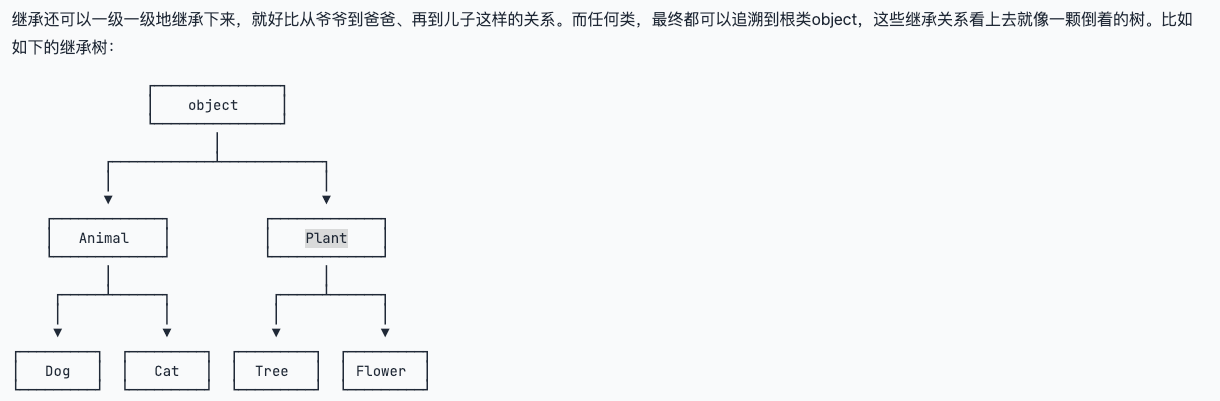

## 静态语言VS动态语言

对于静态语言（例如Java）来说，如果需要传入Animal类型，则传入的对象必须是Animal类型或者它的子类，否则，将无法调用run()方法。

对于Python这样的动态语言来说，则不一定需要传入Animal类型。我们只需要保证传入的对象有一个run()方法就可以了：

In [ ]:
class Timer(object):
    def run(self):
        print('Start...')

animal.py

In [ ]:
class Animal(object):
    def run(self):
        print("Animal is running...")


class Dog(Animal):
    def run(self):
        print("Dog is running...")


class Cat(Animal):
    def run(self):
        print("Cat is running...")


def run_twice(animal):
    animal.run()
    animal.run()


a = Animal()
d = Dog()
c = Cat()

print("a is Animal?", isinstance(a, Animal))
print("a is Dog?", isinstance(a, Dog))
print("a is Cat?", isinstance(a, Cat))

print("d is Animal?", isinstance(d, Animal))
print("d is Dog?", isinstance(d, Dog))
print("d is Cat?", isinstance(d, Cat))

run_twice(c)

get_instance.py

In [ ]:
class Animal(object):
    pass


class Dog(Animal):
    pass


class Husky(Dog):
    pass


a = Animal()
d = Dog()
h = Husky()

print("check a = Animal()...")
print("isinstance(a, Animal) =", isinstance(a, Animal))
print("isinstance(a, Dog) =", isinstance(a, Dog))
print("isinstance(a, Husky) =", isinstance(a, Husky))

print("check d = Dog()...")
print("isinstance(d, Animal) =", isinstance(d, Animal))
print("isinstance(d, Dog) =", isinstance(d, Dog))
print("isinstance(d, Husky) =", isinstance(d, Husky))

print("check h = Husky()...")
print("isinstance(h, Animal) =", isinstance(h, Animal))
print("isinstance(h, Dog) =", isinstance(h, Dog))
print("isinstance(h, Husky) =", isinstance(h, Husky))

其他教程：

https://www.yuque.com/lishibo-kipm2/rgsf35/tax1pfe5ed9ubzm6?singleDoc#

### python内置的多态例子

len()函数

In [ ]:
print(len("hello"))        # 5（字符串）
print(len([1, 2, 3]))      # 3（列表）
print(len({'a': 1, 'b': 2}))  # 2（字典）

 + 运算符

In [ ]:
print(1 + 2)              # 3（数字相加）
print("hello" + "world")  # helloworld（字符串拼接）
print([1, 2] + [3, 4])    # [1, 2, 3, 4]（列表拼接）

还有for循环

### 自己玩玩

In [17]:
class Animal(object):   #编写Animal类
    def run(self):
        print("Animal is running...")

class Dog(Animal):  #Dog类继承Amimal类，没有run方法
    pass

class Cat(Animal):  #Cat类继承Animal类，有自己的run方法
    def run(self):
        print('Cat is running...')
    pass

class Car(object):  #Car类不继承，有自己的run方法
    def run(self):
        print('Car is running...')

class Stone(object):  #Stone类不继承，也没有run方法
    pass

def run_twice(animal):
    animal.run()
    animal.run()

run_twice(Animal())
run_twice(Dog())
run_twice(Cat())
run_twice(Car())
run_twice(Stone())

Animal is running...
Animal is running...
Animal is running...
Animal is running...
Cat is running...
Cat is running...
Car is running...
Car is running...


AttributeError: 'Stone' object has no attribute 'run'

## 获取对象信息

判断对象函数，用 type()函数

type()函数返回的是class的类型，我们在if语句中判断的话，就需要比较两个变量的type类型是否一样

In [ ]:
>>> type(123)==type(456)
True
>>> type(123)==int
True
>>> type('abc')==type('123')
True
>>> type('abc')==str
True
>>> type('abc')==type(123)
False

判断基本的数据类型可以写 int , str 等等，如果判断的东西是否是函数的话，可以用 types 模块中的定义的常量

In [3]:
import types

def fn():
    pass

type(fn)==types.FunctionType

type(abs)==types.BuiltinFunctionType

type(lambda x: x)==types.LambdaType

type((x for x in range(10)))==types.GeneratorType

True

### 使用isinstance()

判断class的类型，可以使用isinstance()函数。

object -> Animal -> Dog -> Husky


能用type()判断的基本类型也可以用isinstance()判断：

In [ ]:
>>> isinstance('a', str)
True
>>> isinstance(123, int)
True
>>> isinstance(b'a', bytes)
True

### 使用dir(

如果要获得一个对象的所有属性和方法，可以使用dir()函数，它返回一个包含字符串的list，比如，获得一个str对象的所有属性和方法：

In [ ]:
>>> dir('ABC')
['__add__', '__class__',..., '__subclasshook__', 'capitalize', 'casefold',..., 'zfill']

类似__xxx__的属性和方法在Python中都是有特殊用途的，比如__len__方法返回长度。在Python中，如果你调用len()函数试图获取一个对象的长度，实际上，在len()函数内部，它自动去调用该对象的__len__()方法，所以，下面的代码是等价的：

In [4]:
len('ABC')

3

In [5]:
'ABC'.__len__()

3

In [8]:
class MyDog(object):
    def __len__(self):
        return 100

dog = MyDog()
len(dog)

100

In [9]:
'ABC'.lower()

'abc'

仅仅把属性和方法列出来是不够的，配合getattr()、setattr()以及hasattr()，我们可以直接操作一个对象的状态：

In [10]:
class MyObject(object):
    def __init__(self):
        self.x = 9
    def power(self):
        return self.x * self.x

obj = MyObject()


In [11]:
hasattr(obj, 'x') # 有属性'x'吗？

True

In [12]:
obj.x

9

In [14]:
hasattr(obj , 'x')

True

In [15]:
hasattr(obj , 'y')

False

In [16]:
setattr(obj, 'y', 19) # 设置一个属性'y'
hasattr(obj, 'y') # 有属性'y'吗？

True

In [17]:
getattr(obj, 'y') # 获取属性'y'

19

In [18]:
obj.y # 获取属性'y'

19

如果试图获取不存在的属性，会抛出AttributeError的错误：

In [19]:
getattr(obj, 'z') # 获取属性'z'

AttributeError: 'MyObject' object has no attribute 'z'

可以传入一个default参数，如果属性不存在，就返回默认值：

In [20]:
getattr(obj, 'z', 404) # 获取属性'z'，如果不存在，返回默认值404

404

## 小结

通过内置的一系列函数，我们可以对任意一个Python对象进行剖析，拿到其内部的数据。要注意的是，只有在不知道对象信息的时候，我们才会去获取对象信息。如果可以直接写：

In [ ]:
sum = obj.x + obj.y

就不要写：

In [ ]:
sum = getattr(obj, 'x') + getattr(obj, 'y')

一个正确的用法的例子如下：

In [ ]:
def readImage(fp):
    if hasattr(fp, 'read'):
        return readData(fp)
    return None

假设我们希望从文件流fp中读取图像，我们首先要判断该fp对象是否存在read方法，如果存在，则该对象是一个流，如果不存在，则无法读取。hasattr()就派上了用场。

请注意，在Python这类动态语言中，根据鸭子类型，有read()方法，不代表该fp对象就是一个文件流，它也可能是网络流，也可能是内存中的一个字节流，但只要read()方法返回的是有效的图像数据，就不影响读取图像的功能。

## 实例属性和类属性

由于Python是动态语言，根据类创建的实例可以任意绑定属性。

给实例绑定属性的方法是通过实例变量，或者通过self变量：

In [21]:
class Student(object):
    def __init__(self, name):
        self.name = name

s = Student('Bob')
s.score = 90


但是，如果Student类本身需要绑定一个属性呢？可以直接在class中定义属性，这种属性是类属性，归Student类所有：

In [ ]:
class Student(object):
    name = 'Student'

当我们定义了一个类属性后，这个属性虽然归类所有，但类的所有实例都可以访问到。来测试一下：

In [22]:
class Student(object):
     name = 'Student'

s = Student() # 创建实例s
print(s.name) # 打印name属性，因为实例并没有name属性，所以会继续查找class的name属性

Student


In [23]:
print(Student.name) # 打印类的name属性

Student


In [24]:
s.name = 'Michael' # 给实例绑定name属性
print(s.name) # 由于实例属性优先级比类属性高，因此，它会屏蔽掉类的name属性

Michael


In [25]:
print(Student.name) # 但是类属性并未消失，用Student.name仍然可以访问

Student


从上面的例子可以看出，在编写程序的时候，千万不要对实例属性和类属性使用相同的名字，因为相同名称的实例属性将屏蔽掉类属性，但是当你删除实例属性后，再使用相同的名称，访问到的将是类属性。

## 练习

为了统计学生人数，可以给Student类增加一个类属性，每创建一个实例，该属性自动增加：

In [26]:
class Student(object):
    count = 0

    def __init__(self, name):
        self.name = name

# 测试:
if Student.count != 0:
    print('测试失败!')
else:
    bart = Student('Bart')
    if Student.count != 1:
        print('测试失败!')
    else:
        lisa = Student('Bart')
        if Student.count != 2:
            print('测试失败!')
        else:
            print('Students:', Student.count)
            print('测试通过!')

测试失败!


In [27]:
class Student(object):
    count = 0

    def __init__(self, name):
        self.name = name
        Student.count += 1

# 测试:
if Student.count != 0:
    print('测试失败!')
else:
    bart = Student('Bart')
    if Student.count != 1:
        print('测试失败!')
    else:
        lisa = Student('Bart')
        if Student.count != 2:
            print('测试失败!')
        else:
            print('Students:', Student.count)
            print('测试通过!')

Students: 2
测试通过!


### 小结

实例属性属于各个实例所有，互不干扰；

类属性属于类所有，所有实例共享一个属性；

不要对实例属性和类属性使用相同的名字，否则将产生难以发现的错误。

# 面向对象高级编程

## 使用__slots__

1.1 正常情况下，当我们定义了一个class，创建了一个class的实例后，我们可以给该实例绑定任何属性和方法，这就是动态语言的灵活性。先定义class：

In [36]:
class Student(object):
    pass

尝试给实例绑定一个属性：

In [45]:
class Student(object):
    pass

s = Student()
s.name = 'Michael' # 动态给实例绑定一个属性
print(s.name)

Michael


尝试给实例绑定一个方法：

In [46]:
def set_age(self, age): # 定义一个函数作为实例方法
    self.age = age

from types import MethodType
s.set_age = MethodType(set_age, s) # 给实例绑定一个方法
s.set_age(25) # 调用实例方法
s.age # 测试结果

25

给一个实例绑定的方法，对另一个实例是不起作用的：

In [38]:
s2 = Student() # 创建新的实例
s2.set_age(25) # 尝试调用方法

AttributeError: 'Student' object has no attribute 'set_age'

为了给所有实例都绑定方法，可以给class绑定方法：

In [49]:
def set_score(self, score):
    self.score = score

Student.set_score = set_score

给class绑定方法后，所有实例均可调用：

In [51]:
s.set_score(100)
s.score

s2.set_score(99)
s2.score

99

通常情况下，上面的set_score方法可以直接定义在class中，但动态绑定允许我们在程序运行的过程中动态给class加上功能，这在静态语言中很难实现。

使用 __slots__

但是，如果我们想要限制实例的属性怎么办？比如，只允许对Student实例添加name和age属性。

为了达到限制的目的，Python允许在定义class的时候，定义一个特殊的__slots__变量，来限制该class实例能添加的属性：

In [52]:
class Student(object):
    __slots__ = ('name', 'age') # 用tuple定义允许绑定的属性名称

In [53]:
s = Student() # 创建新的实例
s.name = 'Michael' # 绑定属性'name'
s.age = 25 # 绑定属性'age'
s.score = 99 # 绑定属性'score'

AttributeError: 'Student' object has no attribute 'score' and no __dict__ for setting new attributes

由于'score'没有被放到__slots__中，所以不能绑定score属性，试图绑定score将得到AttributeError的错误。

使用__slots__要注意，__slots__定义的属性仅对当前类实例起作用，对继承的子类是不起作用的：



In [55]:
class GraduateStudent(Student):
      pass

g = GraduateStudent()
g.score = 9999


除非在子类中也定义__slots__，这样，子类实例允许定义的属性就是自身的__slots__加上父类的__slots__。

子类slot的范围无论有没有父类的，最后的限制范围一定要加上父类的，不然就是非我族类

## 1.2 使用@property

在绑定属性时，如果我们直接把属性暴露出去，虽然写起来很简单，但是，没办法检查参数，导致可以把成绩随便改：

In [ ]:
s = Student()
s.score = 9999

这显然不合逻辑。为了限制score的范围，可以通过一个set_score()方法来设置成绩，再通过一个get_score()来获取成绩，这样，在set_score()方法里，就可以检查参数：

In [57]:
class Student(object):
    def get_score(self):
         return self._score

    def set_score(self, value):
        if not isinstance(value, int):
            raise ValueError('score must be an integer!')
        if value < 0 or value > 100:
            raise ValueError('score must between 0 ~ 100!')
        self._score = value


现在，对任意的Student实例进行操作，就不能随心所欲地设置score了：

In [ ]:
>>> s = Student()
>>> s.set_score(60) # ok!
>>> s.get_score()
60
>>> s.set_score(9999)
Traceback (most recent call last):
  ...
ValueError: score must between 0 ~ 100!

但是，上面的调用方法又略显复杂，没有直接用属性这么直接简单。

有没有既能检查参数，又可以用类似属性这样简单的方式来访问类的变量呢？对于追求完美的Python程序员来说，这是必须要做到的！

还记得装饰器（decorator）可以给函数动态加上功能吗？对于类的方法，装饰器一样起作用。Python内置的@property装饰器就是负责把一个方法变成属性调用的：

In [59]:
class Student(object):
    @property
    def score(self):
        return self._score

    @score.setter
    def score(self, value):
        if not isinstance(value, int):
            raise ValueError('score must be an integer!')
        if value < 0 or value > 100:
            raise ValueError('score must between 0 ~ 100!')
        self._score = value

@property的实现比较复杂，我们先考察如何使用。把一个getter方法变成属性，只需要加上@property就可以了，此时，@property本身又创建了另一个装饰器@score.setter，负责把一个setter方法变成属性赋值，于是，我们就拥有一个可控的属性操作：

In [ ]:
>>> s = Student()
>>> s.score = 60 # OK，实际转化为s.score(60)
>>> s.score # OK，实际转化为s.score()
60
>>> s.score = 9999
Traceback (most recent call last):
  ...
ValueError: score must between 0 ~ 100!

注意到这个神奇的@property，我们在对实例属性操作的时候，就知道该属性很可能不是直接暴露的，而是通过getter和setter方法来实现的。

还可以定义只读属性，只定义getter方法，不定义setter方法就是一个只读属性：

In [58]:
class Student(object):
    @property
    def birth(self):
        return self._birth

    @birth.setter
    def birth(self, value):
        self._birth = value

    @property
    def age(self):
        return 2015 - self._birth

上面的birth是可读写属性，而age就是一个只读属性，因为age可以根据birth和当前时间计算出来。

要特别注意：属性的方法名不要和实例变量重名。例如，以下的代码是错误的：

In [61]:
class Student(object):
    # 方法名称和实例变量均为birth:
    @property
    def birth(self):
        return self.birth

这是因为调用s.birth时，首先转换为方法调用，在执行return self.birth时，又视为访问self的属性，于是又转换为方法调用self.birth()，造成无限递归，最终导致栈溢出报错RecursionError。

练习

请利用@property给一个Screen对象加上width和height属性，以及一个只读属性resolution：



In [ ]:
class Screen(object):
    pass

# 测试:
s = Screen()
s.width = 1024
s.height = 768
print('resolution =', s.resolution)
if s.resolution == 786432:
    print('测试通过!')
else:
    print('测试失败!')


In [62]:
class Screen(object):
    @property
    def width(self):
        return self._width

    @width.setter
    def width(self, value):
        self._width = value

    @property
    def height(self):
        return self._height

    @height.setter
    def height(self, value):
        self._height = value

    @property
    def resolution(self):
        return self._width * self.height


# 测试:
s = Screen()
s.width = 1024
s.height = 768
print('resolution =', s.resolution)
if s.resolution == 786432:
    print('测试通过!')
else:
    print('测试失败!')


resolution = 786432
测试通过!


## @property 是一个装饰器，它只作用于它紧挨着的下一个函数。

# 1.3 多重继承

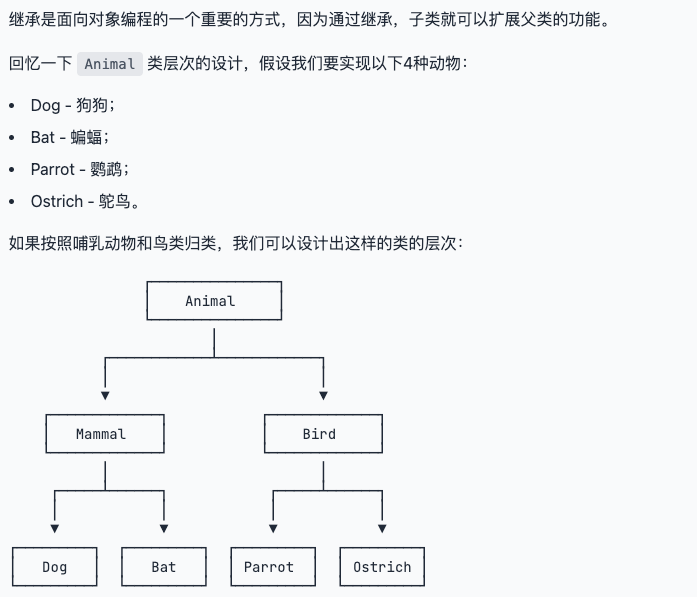

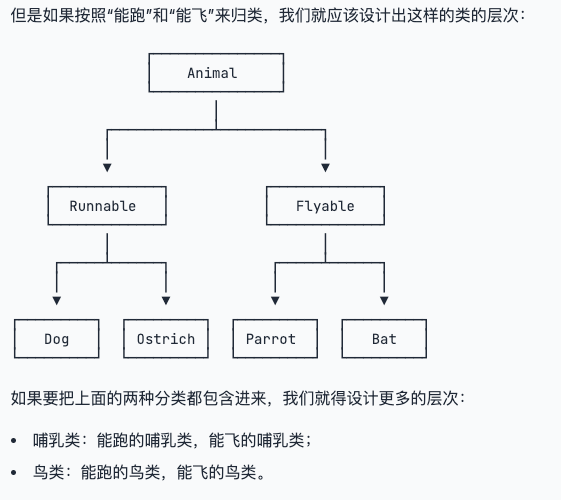

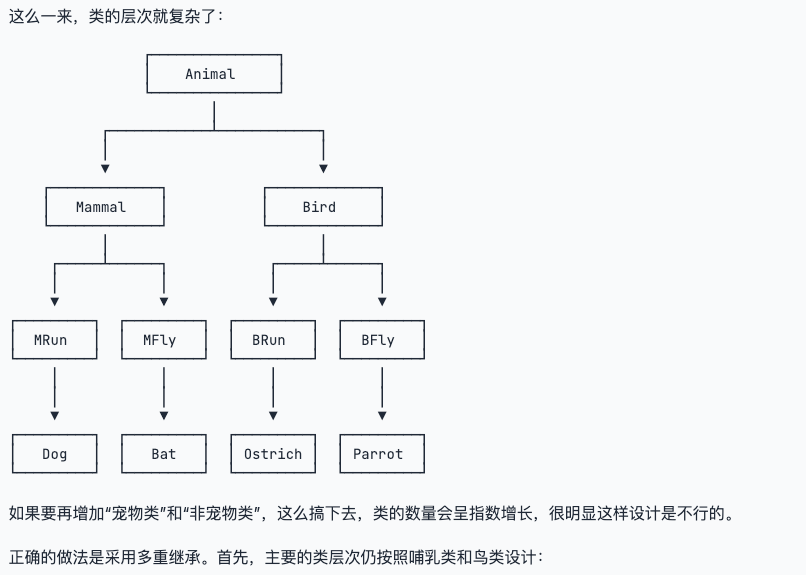

In [63]:
class Animal(object):
    pass

# 大类:
class Mammal(Animal):
    pass

class Bird(Animal):
    pass

# 各种动物:
class Dog(Mammal):
    pass

class Bat(Mammal):
    pass

class Parrot(Bird):
    pass

class Ostrich(Bird):
    pass


现在，我们要给动物再加上Runnable和Flyable的功能，只需要先定义好Runnable和Flyable的类

In [64]:
class Runnable(object):
    def run(self):
        print('Running...')

class Flyable(object):
    def fly(self):
        print('Flying...')

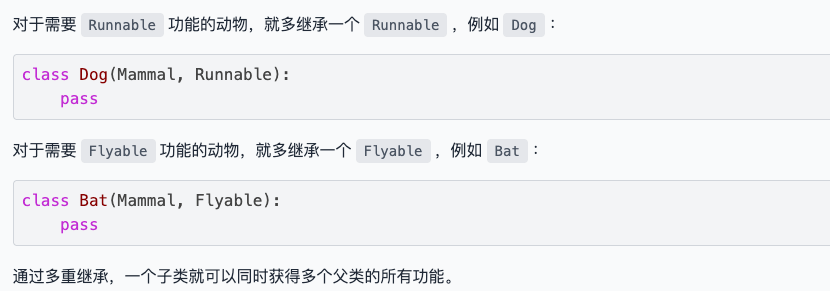

## MixIn

在设计类的继承关系时，通常，主线都是单一继承下来的，例如，Ostrich继承自Bird。但是，如果需要“混入”额外的功能，通过多重继承就可以实现，比如，让Ostrich除了继承自Bird外，再同时继承Runnable。这种设计通常称之为MixIn。

为了更好地看出继承关系，我们把Runnable和Flyable改为RunnableMixIn和FlyableMixIn。类似的，你还可以定义出肉食动物CarnivorousMixIn和植食动物HerbivoresMixIn，让某个动物同时拥有好几个MixIn：

In [ ]:
class Dog(Mammal, RunnableMixIn, CarnivorousMixIn):
    pass

MixIn的目的就是给一个类增加多个功能，这样，在设计类的时候，我们优先考虑通过多重继承来组合多个MixIn的功能，而不是设计多层次的复杂的继承关系。

Python自带的很多库也使用了MixIn。举个例子，Python自带了TCPServer和UDPServer这两类网络服务，而要同时服务多个用户就必须使用多进程或多线程模型，这两种模型由ForkingMixIn和ThreadingMixIn提供。通过组合，我们就可以创造出合适的服务来。

比如，编写一个多进程模式的TCP服务，定义如下：

In [ ]:
class MyTCPServer(TCPServer, ForkingMixIn):
    pass

## 小结
由于Python允许使用多重继承，因此，MixIn就是一种常见的设计。

只允许单一继承的语言（如Java）不能使用MixIn的设计。



## 1.4  定制类

看到类似__slots__这种形如__xxx__的变量或者函数名就要注意，这些在Python中是有特殊用途的。

__slots__我们已经知道怎么用了，__len__()方法我们也知道是为了能让class作用于len()函数。

除此之外，Python的class中还有许多这样有特殊用途的函数，可以帮助我们定制类

## `__str__`

我们先定义一个Student类，打印一个实例：

In [1]:
class Student(object):
    def __init__(self, name):
         self.name = name

print(Student('Michael'))

怎么才能打印得好看呢？只需要定义好__str__()方法，返回一个好看的字符串就可以了：

In [4]:
class Student(object):
    def __init__(self, name):
        self.name = name
    def __str__(self):
        return 'Student object (name: %s)' % self.name

print(Student('Michael'))
s = Student('Michael')
s

Student object (name: Michael)


这样打印出来的实例，不但好看，而且容易看出实例内部重要的数据。

但是细心的朋友会发现直接敲变量不用print，打印出来的实例还是不好看：

这是因为直接显示变量调用的不是__str__()，而是__repr__()，两者的区别是__str__()返回用户看到的字符串，而__repr__()返回程序开发者看到的字符串，也就是说，__repr__()是为调试服务的。

解决办法是再定义一个__repr__()。但是通常__str__()和__repr__()代码都是一样的，所以，有个偷懒的写法：

In [3]:
class Student(object):
    def __init__(self, name):
        self.name = name
    def __str__(self):
        return 'Student object (name=%s)' % self.name
    __repr__ = __str__

## `__iter__`

如果一个类想被用于for ... in循环，类似list或tuple那样，就必须实现一个__iter__()方法，该方法返回一个迭代对象，然后，Python的for循环就会不断调用该迭代对象的__next__()方法拿到循环的下一个值，直到遇到StopIteration错误时退出循环。

我们以斐波那契数列为例，写一个Fib类，可以作用于for循环：

In [5]:
class Fib(object):
    def __init__(self):
        self.a, self.b = 0, 1 # 初始化两个计数器a，b

    def __iter__(self):
        return self # 实例本身就是迭代对象，故返回自己

    def __next__(self):
        self.a, self.b = self.b, self.a + self.b # 计算下一个值
        if self.a > 100000: # 退出循环的条件
            raise StopIteration()
        return self.a # 返回下一个值

In [6]:
for n in Fib():
    print(n)

1
1
2
3
5
8
13
21
34
55
89
144
233
377
610
987
1597
2584
4181
6765
10946
17711
28657
46368
75025


## `__getitem__`

Fib实例虽然能作用于for循环，看起来和list有点像，但是，把它当成list来使用还是不行，比如，取第5个元素：

In [ ]:
>>> Fib()[5]
Traceback (most recent call last):
  File "<stdin>", line 1, in <module>
TypeError: 'Fib' object does not support indexing

要表现得像list那样按照下标取出元素，需要实现__getitem__()方法：

In [7]:
class Fib(object):
    def __getitem__(self, n):
        a, b = 1, 1
        for x in range(n):
            a, b = b, a + b
        return a

In [9]:
f = Fib()
f[0]
f[5]

8

但是list有个神奇的切片方法：

In [ ]:
>>> list(range(100))[5:10]
[5, 6, 7, 8, 9]

对于Fib却报错。原因是__getitem__()传入的参数可能是一个int，也可能是一个切片对象slice，所以要做判断：

In [10]:
class Fib(object):
    def __getitem__(self, n):
        if isinstance(n, int): # n是索引
            a, b = 1, 1
            for x in range(n):
                a, b = b, a + b
            return a
        if isinstance(n, slice): # n是切片
            start = n.start
            stop = n.stop
            if start is None:
                start = 0
            a, b = 1, 1
            L = []
            for x in range(stop):
                if x >= start:
                    L.append(a)
                a, b = b, a + b
            return L

In [11]:
f = Fib()
f[0:5]

[1, 1, 2, 3, 5]

但是没有对step参数作处理：

In [12]:
f[:10:2]

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55]

也没有对负数作处理，所以，要正确实现一个__getitem__()还是有很多工作要做的。

此外，如果把对象看成dict，__getitem__()的参数也可能是一个可以作key的object，例如str。

与之对应的是__setitem__()方法，把对象视作list或dict来对集合赋值。最后，还有一个__delitem__()方法，用于删除某个元素。

总之，通过上面的方法，我们自己定义的类表现得和Python自带的list、tuple、dict没什么区别，这完全归功于动态语言的“鸭子类型”，不需要强制继承某个接口。

## `__getattr__`

正常情况下，当我们调用类的方法或属性时，如果不存在，就会报错。比如定义Student类：

In [13]:
class Student(object):
    def __init__(self):
        self.name = 'Michael'

调用name属性，没问题，但是，调用不存在的score属性，就有问题了：

In [ ]:
>>> s = Student()
>>> print(s.name)
Michael
>>> print(s.score)
Traceback (most recent call last):
  ...
AttributeError: 'Student' object has no attribute 'score'

错误信息很清楚地告诉我们，没有找到score这个attribute。

要避免这个错误，除了可以加上一个score属性外，Python还有另一个机制，那就是写一个__getattr__()方法，动态返回一个属性。修改如下：

In [4]:
class Student(object):
    def __init__(self):
        self.name = 'Michael'

    def __getattr__(self, attr):
        if attr=='score':
            return 99

当调用不存在的属性时，比如score，Python解释器会试图调用__getattr__(self, 'score')来尝试获得属性，这样，我们就有机会返回score的值：

In [7]:
s = Student()
s.name

'Michael'

In [8]:
s.score

99

返回函数也是可以的

In [21]:
class Student(object):
    def __getattr__(self, attr):
        if attr=='age':
            return lambda: 25
    #调用方式需要修改：
    s.age()

TypeError: 'NoneType' object is not callable

注意，只有在没有找到属性的情况下，才调用__getattr__，已有的属性，比如name，不会在__getattr__中查找。

此外，注意到任意调用如s.abc都会返回None，这是因为我们定义的__getattr__默认返回就是None。要让class只响应特定的几个属性，我们就要按照约定，抛出AttributeError的错误：

In [28]:
class Student(object):
    def __getattr__(self, attr):
        if attr=='age':
            return lambda: 25
        raise AttributeError('\'Student\' object has no attribute \'%s\'' % attr)


这实际上可以把一个类的所有属性和方法调用全部动态化处理了，不需要任何特殊手段。

这种完全动态调用的特性有什么实际作用呢？作用就是，可以针对完全动态的情况作调用。

举个例子：

现在很多网站都搞REST API，比如新浪微博、豆瓣啥的，调用API的URL类似：

http://api.server/user/friends
http://api.server/user/timeline/list
如果要写SDK，给每个URL对应的API都写一个方法，那得累死，而且，API一旦改动，SDK也要改。

利用完全动态的__getattr__，我们可以写出一个链式调用：

In [30]:
class Chain(object):
    def __init__(self, path=''):
        self._path = path

    def __getattr__(self, path):
        return Chain('%s/%s' % (self._path, path))

    def __str__(self):
        return self._path

    __repr__ = __str__


In [31]:
Chain().status.user.timeline.list

/status/user/timeline/list

这样，无论API怎么变，SDK都可以根据URL实现完全动态的调用，而且，不随API的增加而改变！

还有些REST API会把参数放到URL中，比如GitHub的API：

In [ ]:
GET /users/:user/repos

调用时，需要把:user替换为实际用户名。如果我们能写出这样的链式调用：

In [32]:
Chain().users('michael').repos

TypeError: 'Chain' object is not callable

就可以非常方便地调用API了。有兴趣的童鞋可以试试写出来。

我的完成情况：

In [35]:
class Chain(object):
    def __init__(self, path=''):
        self._path = path

    def __getattr__(self, name):
        return Chain(f'{self._path}/{name}')

    def __call__(self, value):
        return Chain(f'{self._path}/{value}')

    def __str__(self):
        return self._path

    __repr__ = __str__

Chain().users('michael').repos

/users/michael/repos

## `__call__`

一个对象实例可以有自己的属性和方法，当我们调用实例方法时，我们用instance.method()来调用。能不能直接在实例本身上调用呢？在Python中，答案是肯定的。

任何类，只需要定义一个__call__()方法，就可以直接对实例进行调用。请看示例：

In [36]:
class Student(object):
    def __init__(self, name):
        self.name = name

    def __call__(self):
        print('My name is %s.' % self.name)

s = Student('Michael')
s()

My name is Michael.


`__call__()`还可以定义参数。对实例进行直接调用就好比对一个函数进行调用一样，所以你完全可以把对象看成函数，把函数看成对象，因为这两者之间本来就没啥根本的区别。

如果你把对象看成函数，那么函数本身其实也可以在运行期动态创建出来，因为类的实例都是运行期创建出来的，这么一来，我们就模糊了对象和函数的界限。

那么，怎么判断一个变量是对象还是函数呢？其实，更多的时候，我们需要判断一个对象是否能被调用，能被调用的对象就是一个Callable对象，比如函数和我们上面定义的带有__call__()的类实例：

In [ ]:
>>> callable(Student())
True
>>> callable(max)
True
>>> callable([1, 2, 3])
False
>>> callable(None)
False
>>> callable('str')
False

# 1.5 使用枚举类

当我们需要定义常量时，一个办法是用大写变量通过整数来定义，例如月份：

In [ ]:
JAN = 1
FEB = 2
MAR = 3
...
NOV = 11
DEC = 12

好处是简单，缺点是类型是int，并且仍然是变量。

更好的方法是为这样的枚举类型定义一个class类型，然后，每个常量都是class的一个唯一实例。Python提供了Enum类来实现这个功能：

In [38]:
from enum import Enum

Month = Enum('Month', ('Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'))

这样我们就获得了Month类型的枚举类，可以直接使用Month.Jan来引用一个常量，或者枚举它的所有成员：

In [39]:
for name, member in Month.__members__.items():
    print(name, '=>', member, ',', member.value)

Jan => Month.Jan , 1
Feb => Month.Feb , 2
Mar => Month.Mar , 3
Apr => Month.Apr , 4
May => Month.May , 5
Jun => Month.Jun , 6
Jul => Month.Jul , 7
Aug => Month.Aug , 8
Sep => Month.Sep , 9
Oct => Month.Oct , 10
Nov => Month.Nov , 11
Dec => Month.Dec , 12


value属性则是自动赋给成员的int常量，默认从1开始计数。

如果需要更精确地控制枚举类型，可以从Enum派生出自定义类：

In [40]:
from enum import Enum, unique

@unique
class Weekday(Enum):
    Sun = 0 # Sun的value被设定为0
    Mon = 1
    Tue = 2
    Wed = 3
    Thu = 4
    Fri = 5
    Sat = 6

@unique装饰器可以帮助我们检查保证没有重复值。

访问这些枚举类型可以有若干种方法：

In [ ]:
>>> day1 = Weekday.Mon
>>> print(day1)
Weekday.Mon
>>> print(Weekday.Tue)
Weekday.Tue
>>> print(Weekday['Tue'])
Weekday.Tue
>>> print(Weekday.Tue.value)
2
>>> print(day1 == Weekday.Mon)
True
>>> print(day1 == Weekday.Tue)
False
>>> print(Weekday(1))
Weekday.Mon
>>> print(day1 == Weekday(1))
True
>>> Weekday(7)
Traceback (most recent call last):
  ...
ValueError: 7 is not a valid Weekday
>>> for name, member in Weekday.__members__.items():
...     print(name, '=>', member)
...
Sun => Weekday.Sun
Mon => Weekday.Mon
Tue => Weekday.Tue
Wed => Weekday.Wed
Thu => Weekday.Thu
Fri => Weekday.Fri
Sat => Weekday.Sat

## 练习

把Student的gender属性改造为枚举类型，可以避免使用字符串：

In [47]:
from enum import Enum, unique

class Gender(Enum):
    Male = 0
    Female = 1

class Student(object):
    def __init__(self, name, gender):
        self.name = name
        self.gender = gender

# 测试:
bart = Student('Bart', 'Gender.Male')
if bart.gender == Gender.Male:
    print('测试通过!')
else:
    print('测试失败!')

测试失败!


In [44]:
from enum import Enum, unique

@unique
class Gender(Enum):
    Male = 0
    Female = 1

class Student(object):
    def __init__(self, name, gender: Gender):
        if not isinstance(gender, Gender):
            raise ValueError('gender must be Gender')
        self.name = name
        self.gender = gender

# 测试:
bart = Student('Bart', Gender.Male)
if bart.gender == Gender.Male:
    print('测试通过!')
else:
    print('测试失败!')

测试通过!


## 1.6 使用元类

type()
动态语言和静态语言最大的不同，就是函数和类的定义，不是编译时定义的，而是运行时动态创建的。

比方说我们要定义一个Hello的class，就写一个hello.py模块：

In [58]:
class Hello(object):
    def hello(self, name='world'):
        print('Hello, %s.' % name)


h = Hello()
h.hello()

Hello, world.


当Python解释器载入hello模块时，就会依次执行该模块的所有语句，执行结果就是动态创建出一个Hello的class对象，测试如下：

In [56]:
print(type(Hello))

<class 'type'>


In [59]:
print(type(h))

<class '__main__.Hello'>


type()函数可以查看一个类型或变量的类型，Hello是一个class，它的类型就是type，而h是一个实例，它的类型就是class Hello。

我们说class的定义是运行时动态创建的，而创建class的方法就是使用type()函数。

type()函数既可以返回一个对象的类型，又可以创建出新的类型，比如，我们可以通过type()函数创建出Hello类，而无需通过class Hello(object)...的定义：

要创建一个class对象，type()函数依次传入3个参数：

class的名称；

继承的父类集合，注意Python支持多重继承，如果只有一个父类，别忘了tuple的单元素写法；

class的方法名称与函数绑定，这里我们把函数fn绑定到方法名hello上。

通过type()函数创建的类和直接写class是完全一样的，因为Python解释器遇到class定义时，仅仅是扫描一下class定义的语法，然后调用type()函数创建出class。

正常情况下，我们都用class Xxx...来定义类，但是，type()函数也允许我们动态创建出类来，也就是说，动态语言本身支持运行期动态创建类，这和静态语言有非常大的不同，要在静态语言运行期创建类，必须构造源代码字符串再调用编译器，或者借助一些工具生成字节码实现，本质上都是动态编译，会非常复杂。

### metaclass

除了使用type()动态创建类以外，要控制类的创建行为，还可以使用metaclass。

metaclass，直译为元类，简单的解释就是：

当我们定义了类以后，就可以根据这个类创建出实例，所以：先定义类，然后创建实例。

但是如果我们想创建出类呢？那就必须根据metaclass创建出类，所以：先定义metaclass，然后创建类。

连接起来就是：先定义metaclass，就可以创建类，最后创建实例。

所以，metaclass允许你创建类或者修改类。换句话说，你可以把类看成是metaclass创建出来的“实例”。

metaclass是Python面向对象里最难理解，也是最难使用的魔术代码。正常情况下，你不会碰到需要使用metaclass的情况，所以，以下内容看不懂也没关系，因为基本上你不会用到。

我们先看一个简单的例子，这个metaclass可以给我们自定义的MyList增加一个add方法：

定义ListMetaclass，按照默认习惯，metaclass的类名总是以Metaclass结尾，以便清楚地表示这是一个metaclass：

In [60]:
# metaclass是类的模板，所以必须从`type`类型派生：
class ListMetaclass(type):
    def __new__(cls, name, bases, attrs):
        attrs['add'] = lambda self, value: self.append(value)
        return type.__new__(cls, name, bases, attrs)


有了ListMetaclass，我们在定义类的时候还要指示使用ListMetaclass来定制类，传入关键字参数metaclass：

In [61]:
class MyList(list, metaclass=ListMetaclass):
    pass

当我们传入关键字参数metaclass时，魔术就生效了，它指示Python解释器在创建MyList时，要通过ListMetaclass.__new__()来创建，在此，我们可以修改类的定义，比如，加上新的方法，然后，返回修改后的定义。

__new__()方法接收到的参数依次是：

当前准备创建的类的对象；

类的名字；

类继承的父类集合；

类的方法集合。

测试一下MyList是否可以调用add()方法：

In [63]:
L = MyList()
L.add(1)
L

[1]

而普通的list没有add()方法：

In [64]:
L2 = list()
L2.add(1)

AttributeError: 'list' object has no attribute 'add'

动态修改有什么意义？直接在MyList定义中写上add()方法不是更简单吗？正常情况下，确实应该直接写，通过metaclass修改纯属变态。

但是，总会遇到需要通过metaclass修改类定义的。ORM就是一个典型的例子。

ORM全称“Object Relational Mapping”，即对象-关系映射，就是把关系数据库的一行映射为一个对象，也就是一个类对应一个表，这样，写代码更简单，不用直接操作SQL语句。

要编写一个ORM框架，所有的类都只能动态定义，因为只有使用者才能根据表的结构定义出对应的类来。

让我们来尝试编写一个ORM框架。

编写底层模块的第一步，就是先把调用接口写出来。比如，使用者如果使用这个ORM框架，想定义一个User类来操作对应的数据库表User，我们期待他写出这样的代码：

In [ ]:
class User(Model):
    # 定义类的属性到列的映射：
    id = IntegerField('id')
    name = StringField('username')
    email = StringField('email')
    password = StringField('password')

# 创建一个实例：
u = User(id=12345, name='Michael', email='test@orm.org', password='my-pwd')
# 保存到数据库：
u.save()

其中，父类Model和属性类型StringField、IntegerField是由ORM框架提供的，剩下的魔术方法比如save()全部由父类Model自动完成。虽然metaclass的编写会比较复杂，但ORM的使用者用起来却异常简单。

现在，我们就按上面的接口来实现该ORM。

首先来定义Field类，它负责保存数据库表的字段名和字段类型：

In [65]:
class Field(object):

    def __init__(self, name, column_type):
        self.name = name
        self.column_type = column_type

    def __str__(self):
        return '<%s:%s>' % (self.__class__.__name__, self.name)

在Field的基础上，进一步定义各种类型的Field，比如StringField，IntegerField等等：

In [ ]:
class StringField(Field):
    def __init__(self, name):
        super(StringField, self).__init__(name, 'varchar(100)')

class IntegerField(Field):
    def __init__(self, name):
        super(IntegerField, self).__init__(name, 'bigint')

编写复杂的ModelMetaclass

In [ ]:
class ModelMetaclass(type):
    def __new__(cls, name, bases, attrs):
        if name=='Model':
            return type.__new__(cls, name, bases, attrs)
        print('Found model: %s' % name)
        mappings = dict()
        for k, v in attrs.items():
            if isinstance(v, Field):
                print('Found mapping: %s ==> %s' % (k, v))
                mappings[k] = v
        for k in mappings.keys():
            attrs.pop(k)
        attrs['__mappings__'] = mappings # 保存属性和列的映射关系
        attrs['__table__'] = name # 假设表名和类名一致
        return type.__new__(cls, name, bases, attrs)

基类model:

In [ ]:
class Model(dict, metaclass=ModelMetaclass):
    def __init__(self, **kw):
        super(Model, self).__init__(**kw)

    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(r"'Model' object has no attribute '%s'" % key)

    def __setattr__(self, key, value):
        self[key] = value

    def save(self):
        fields = []
        params = []
        args = []
        for k, v in self.__mappings__.items():
            fields.append(v.name)
            params.append('?')
            args.append(getattr(self, k, None))
        sql = 'insert into %s (%s) values (%s)' % (self.__table__, ','.join(fields), ','.join(params))
        print('SQL: %s' % sql)
        print('ARGS: %s' % str(args))

当用户定义一个class User(Model)时，Python解释器首先在当前类User的定义中查找metaclass，如果没有找到，就继续在父类Model中查找metaclass，找到了，就使用Model中定义的metaclass的ModelMetaclass来创建User类，也就是说，metaclass可以隐式地继承到子类，但子类自己却感觉不到。

在ModelMetaclass中，一共做了几件事情：

排除掉对Model类的修改；
在当前类（比如User）中查找定义的类的所有属性，如果找到一个Field属性，就把它保存到一个__mappings__的dict中，同时从类属性中删除该Field属性，否则，容易造成运行时错误（实例的属性会遮盖类的同名属性）；
把表名保存到__table__中，这里简化为表名默认为类名。
在Model类中，就可以定义各种操作数据库的方法，比如save()，delete()，find()，update等等。

我们实现了save()方法，把一个实例保存到数据库中。因为有表名，属性到字段的映射和属性值的集合，就可以构造出INSERT语句。

对 95% 的开发者：不需要自己写元类，但需要理解框架中的元类

对 5% 的开发者（库/框架开发者）：需要深入掌握

AI 可以：生成 90% 的元类代码，但你需要理解原理来审查